# La brújula del cerebro: 97 neuronas en murciélagos volando sobre una isla

> **La dirección preferida cambió ~1,72°/s la primera noche y ~0,20°/s la sexta. La brújula se afina con el tiempo.**

**Paper:** Palgi et al., *Science* (2025). DOI: [10.1126/science.adw6202](https://doi.org/10.1126/science.adw6202)
**Video:** [YouTube Short](https://youtube.com/shorts/-g9NA2iroYM)
**Datos:** [Zenodo](https://doi.org/10.5281/zenodo.15646845)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-10-16-brujula-cerebral-murcielagos-isla/notebook.ipynb)

## El experimento

Hasta ahora, las neuronas que codifican dirección (**head-direction cells**, células brújula) se habían estudiado casi siempre en ratas corriendo dentro de una caja. El equipo de Palgi y colaboradores llevó el electrofisiólogo al campo: pusieron sensores inalámbricos en **murciélagos de la fruta** (*Rousettus aegyptiacus*) que volaban libres sobre la selva de **Jozani, en Zanzíbar**, una isla oceánica remota.

Grabaron **97 células brújula** en el presubículo durante varias noches. Queremos ver tres cosas:

1. **¿Cómo se ve una "neurona brújula"?** → 2 ejemplos del paper
2. **¿Cubren todas las direcciones?** → población de 97 células
3. **¿La brújula necesita la luna para orientarse?** → un test de invarianza

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Palgi et al. (2025), Science | Datos: Zenodo 15646845'
COLOR_DATOS = '#2563EB'       # azul CaM — células reales
COLOR_ALERTA = '#DC2626'      # rojo — referencia/umbral
COLOR_SHUFFLE = '#BBBBBB'     # gris — distribución aleatoria
COLOR_ACENTO = '#059669'      # verde — segundo dataset
COLOR_NOCHE_INICIO = '#D97706'  # ámbar — noche 1 (drift alto)
COLOR_NOCHE_FIN = '#2563EB'     # azul — noche 6 (estable)

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback remoto)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Reproducible
np.random.seed(42)

# Cargar CSVs
ejemplos = pd.read_csv('datos/ejemplo_neuronas_brujula.csv')
todas = pd.read_csv('datos/todas_hd_cells_tuning.csv')
pref_dirs = pd.read_csv('datos/direcciones_preferidas.csv')
estab_noche = pd.read_csv('datos/estabilidad_por_noche.csv')
luna_delta = pd.read_csv('datos/luna_delta_preferida.csv')
luna_shuffle = pd.read_csv('datos/luna_shuffle.csv')

print(f'97 células HD (población): {len(pref_dirs)} direcciones preferidas')
print(f'Ejemplos destacados: células {sorted(ejemplos.cell_num.unique())}')
print(f'Estabilización por noche: {len(estab_noche)} registros')
print(f'Split luna: {len(luna_delta)} células (arriba={sum(luna_delta.moon_below_horizon==0)}, '
      f'abajo={sum(luna_delta.moon_below_horizon==1)})')

97 células HD (población): 97 direcciones preferidas
Ejemplos destacados: células [np.int64(38), np.int64(44)]
Estabilización por noche: 77 registros
Split luna: 20 células (arriba=10, abajo=10)


## Mira 97 células al mismo tiempo.

Cada fila es una neurona. Cada columna, una dirección en la que se giró la cabeza del murciélago (de 0° a 360°). El color indica cuánto dispara la neurona cuando la cabeza apunta ahí.

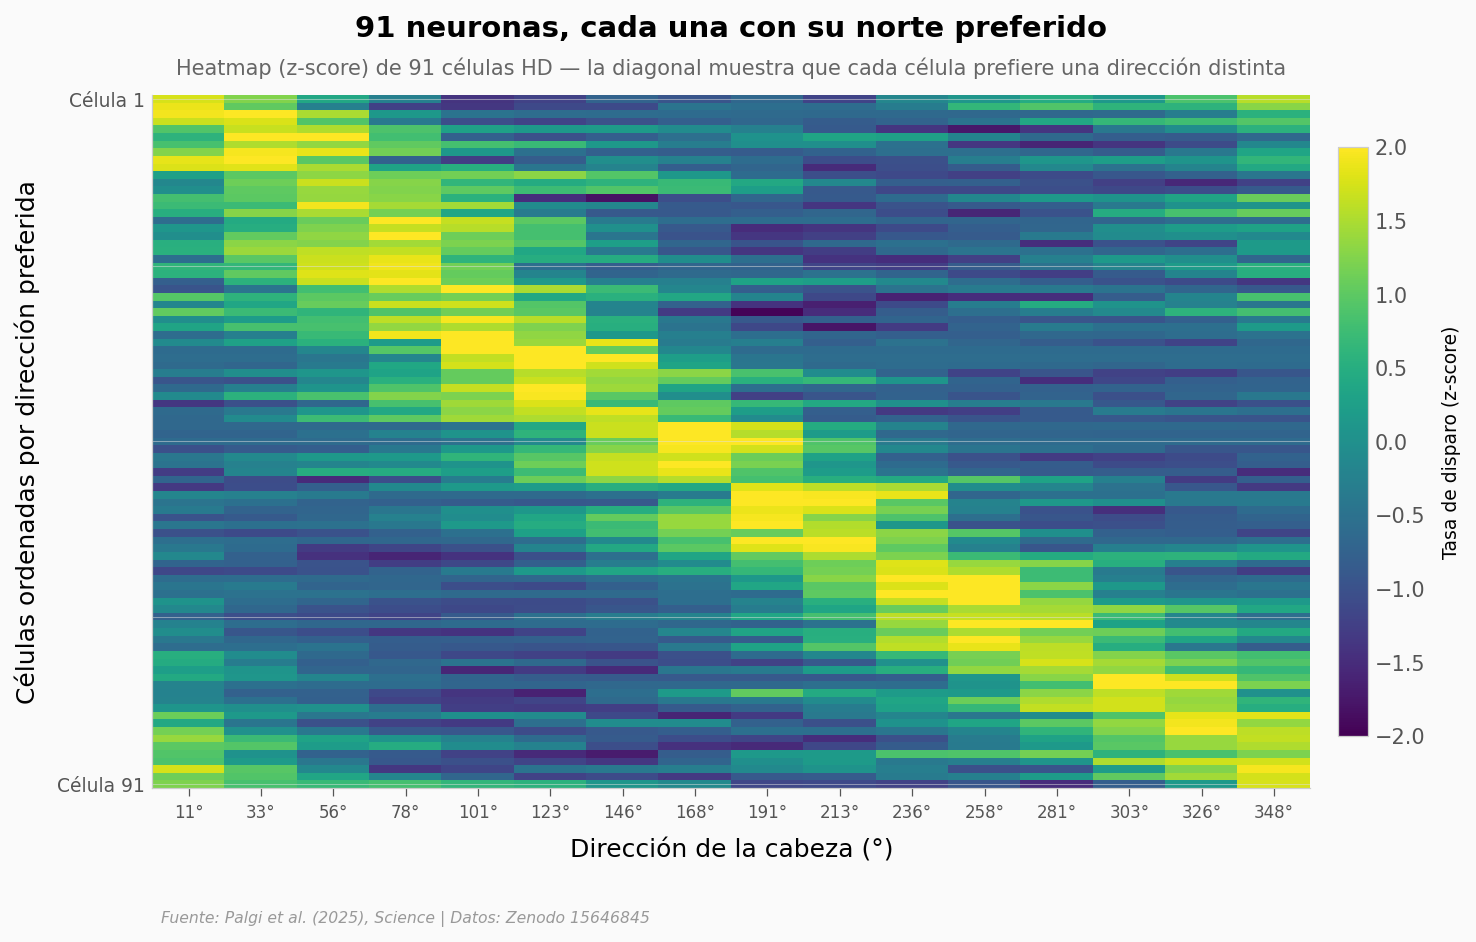

In [2]:
# HERO CHART — heatmap 91 células × 16 bins direccionales
# ordenadas por su dirección preferida. Dropna por NaN (regla de datos).

bin_cols = [c for c in todas.columns if c.startswith('zscore_bin_')]
bin_degs = np.array([int(c.replace('zscore_bin_','')) for c in bin_cols])

# Orden por dirección preferida (del paper: pnlG)
tuning = todas.dropna(subset=bin_cols).copy()
tuning_sorted = tuning.sort_values('preferred_direction_deg').reset_index(drop=True)
matrix = tuning_sorted[bin_cols].values  # shape (91, 16)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(matrix, aspect='auto', cmap='viridis',
               vmin=-2, vmax=2, interpolation='nearest')
ax.set_xticks(np.arange(16))
ax.set_xticklabels([f'{int(d)}°' for d in bin_degs], fontsize=8)
ax.set_yticks([0, 22, 45, 68, 90])
ax.set_yticklabels(['Célula 1', '', '', '', f'Célula {len(tuning_sorted)}'], fontsize=9)
ax.set_xlabel('Dirección de la cabeza (°)')
ax.set_ylabel('Células ordenadas por dirección preferida')

ax.set_title('91 neuronas, cada una con su norte preferido',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Heatmap (z-score) de {len(tuning_sorted)} células HD — '
        'la diagonal muestra que cada célula prefiere una dirección distinta',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Tasa de disparo (z-score)', fontsize=9)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/hero_heatmap_97_celulas.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: la franja amarilla forma una diagonal. Eso quiere decir que cada célula tiene una dirección distinta como su favorita, y que las 91 juntas cubren los 360°. En el paper (figura G): 97 células con direcciones preferidas repartidas en los cuatro cuadrantes (norte 24,7% · este 33,0% · sur 20,6% · oeste 21,6%). La población tilea la rosa de los vientos.

## ¿Y una sola célula, cómo se ve?

Aquí están dos ejemplos del paper (paneles A y B). La distancia al centro mide cuánto dispara; la dirección, hacia dónde apuntaba la cabeza del murciélago. La línea roja es el **ajuste de von Mises**, la curva estándar para medir concentración angular.

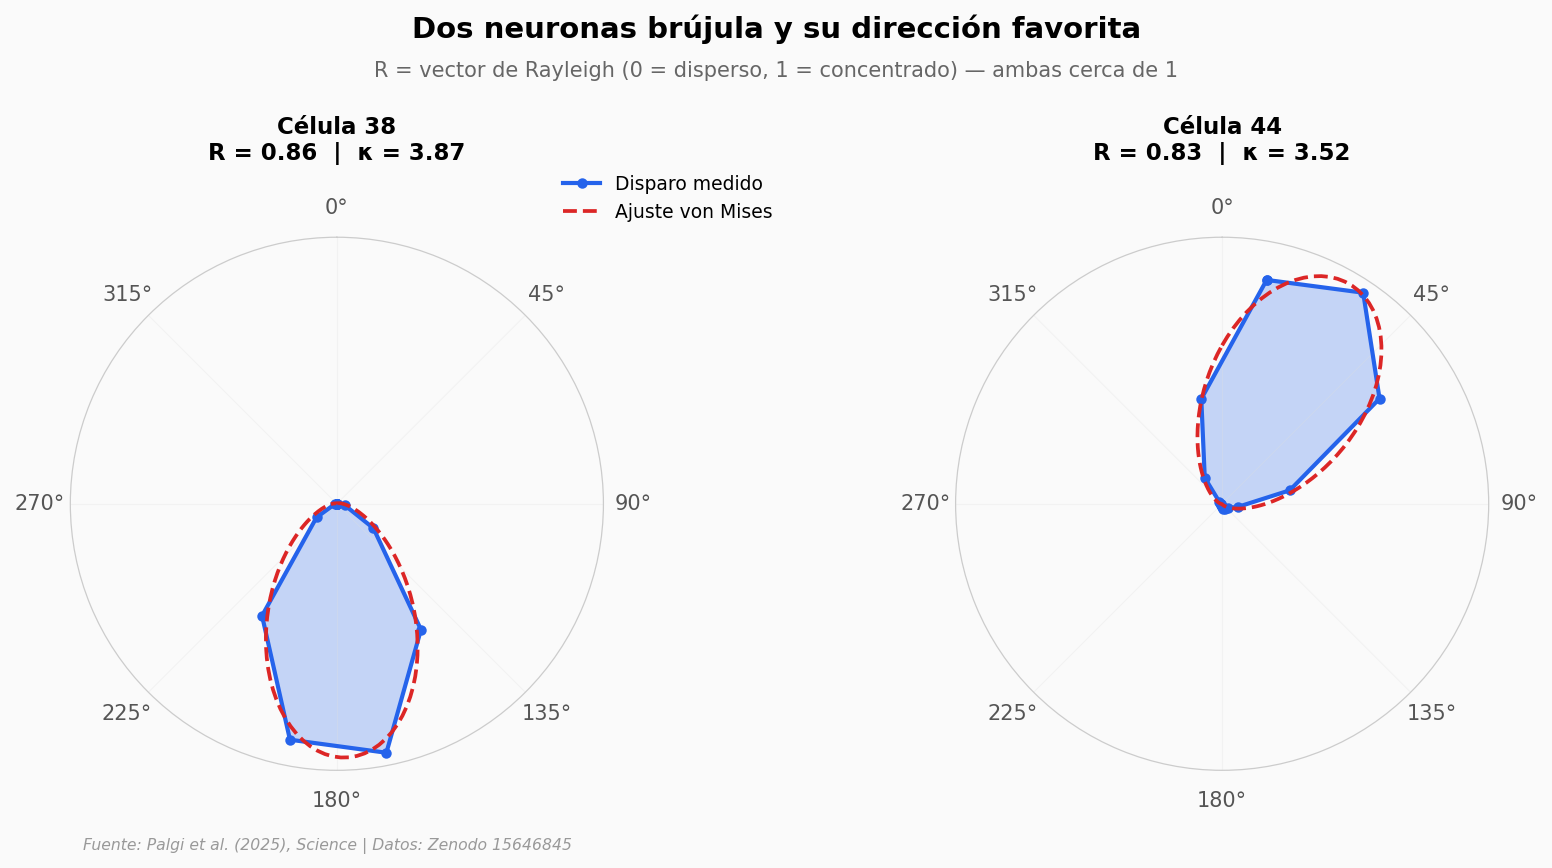

In [3]:
# Polar plots para cells 38 y 44 (hero examples)
cells_to_plot = [38, 44]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), subplot_kw={'projection': 'polar'})

for ax, cnum in zip(axes, cells_to_plot):
    sub = ejemplos[ejemplos.cell_num == cnum].drop_duplicates('bin_deg').sort_values('bin_deg')
    theta = np.deg2rad(sub.bin_deg.values)
    r = sub.firing_rate_hz.values
    # cerrar el polígono
    theta_c = np.append(theta, theta[0])
    r_c = np.append(r, r[0])

    rayleigh = sub.rayleigh_vector.iloc[0]
    kappa = sub.vonmises_kappa.iloc[0]
    mean_deg = sub.vonmises_mean_deg.iloc[0]

    # von Mises fit
    theta_fine = np.linspace(0, 2*np.pi, 200)
    vm = np.exp(kappa * np.cos(theta_fine - np.deg2rad(mean_deg)))
    vm = vm / vm.max() * r.max()

    ax.fill(theta_c, r_c, color=COLOR_DATOS, alpha=0.25)
    ax.plot(theta_c, r_c, color=COLOR_DATOS, linewidth=2, marker='o', markersize=4,
            label='Disparo medido')
    ax.plot(theta_fine, vm, color=COLOR_ALERTA, linewidth=1.8, linestyle='--',
            label='Ajuste von Mises')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(f'Célula {cnum}\nR = {rayleigh:.2f}  |  κ = {kappa:.2f}',
                 fontsize=11, fontweight='bold', pad=18)
    ax.set_rticks([])
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9, framealpha=0.9)

fig.suptitle('Dos neuronas brújula y su dirección favorita',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 0.96, 'R = vector de Rayleigh (0 = disperso, 1 = concentrado) — ambas cerca de 1',
         fontsize=10, color='#666666', ha='center')

fig.text(0.08, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/polar_ejemplos_cells_38_44.png', dpi=200, bbox_inches='tight')
plt.show()

## La brújula se calibra con las noches

El paper hace algo lindo: los murciélagos llegan a la isla, salen a volar noche a noche, y el equipo mide cuánto **cambia (drifta)** la dirección preferida de cada célula dentro de una sesión.

La predicción: si la brújula es *aprendida*, debería drift más al principio y estabilizarse con el tiempo. Los datos (panel D del paper) sí muestran eso.

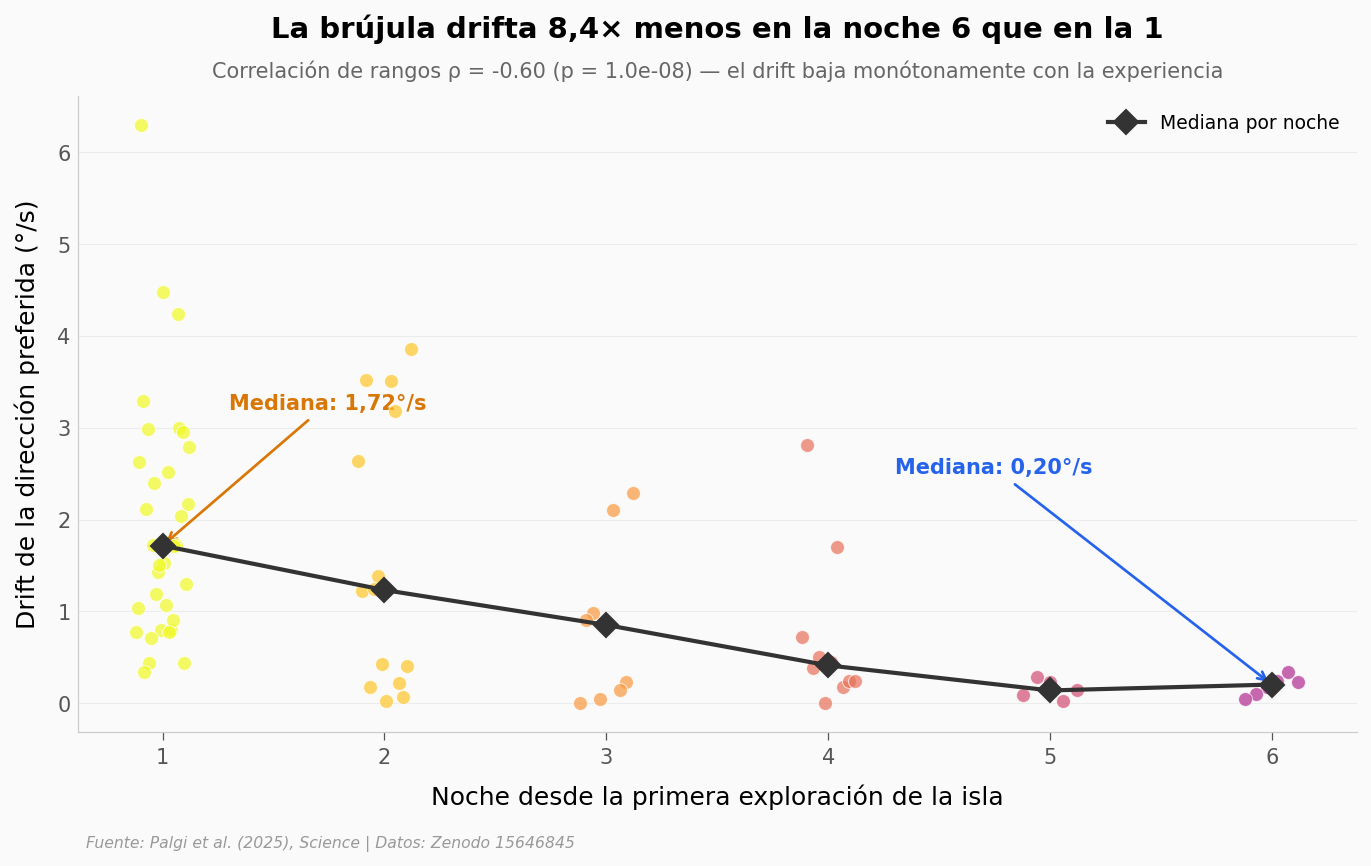

Mediana noche 1: 1.716°/s (n=33)
Mediana noche 6: 0.204°/s (n=6)
Factor de reducción entre medianas: 8.4×
Spearman ρ (todas las células, N=77): -0.596, p = 1.04e-08
Mann-Whitney U (1-sided, noche1 > noche6): p = 6.13e-07
Cohen d (pooled) = 1.43 — efecto grande (>0,8)


In [4]:
# Drift por noche (1 a 6). Boxplot + scatter por célula.

night_data = [estab_noche[estab_noche.night_num == n].pref_direction_slope_deg_per_s.values
              for n in range(1, 7)]

fig, ax = plt.subplots(figsize=(11, 5.5))

# Scatter con jitter reproducible
np.random.seed(42)
for i, vals in enumerate(night_data, start=1):
    if len(vals) == 0:
        continue
    x_jit = np.linspace(i - 0.12, i + 0.12, len(vals))
    np.random.shuffle(x_jit)
    # color interpola entre naranja (noche 1) y azul (noche 6)
    frac = (i - 1) / 5
    color = plt.cm.plasma(1 - frac * 0.6)
    ax.scatter(x_jit, vals, s=45, color=color, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)

# Medianas conectadas
medianas = [np.median(v) if len(v) else np.nan for v in night_data]
ax.plot(range(1, 7), medianas, color='#333333', linewidth=2,
        marker='D', markersize=8, zorder=6, label='Mediana por noche')

# Anotaciones para noche 1 y 6
ax.annotate(f'Mediana: 1,72°/s',
            xy=(1, 1.716), xytext=(1.3, 3.2),
            fontsize=10, fontweight='bold', color=COLOR_NOCHE_INICIO,
            arrowprops=dict(arrowstyle='->', color=COLOR_NOCHE_INICIO, lw=1.3))
ax.annotate(f'Mediana: 0,20°/s',
            xy=(6, 0.204), xytext=(4.3, 2.5),
            fontsize=10, fontweight='bold', color=COLOR_NOCHE_FIN,
            arrowprops=dict(arrowstyle='->', color=COLOR_NOCHE_FIN, lw=1.3))

# Spearman sobre todas las células
rho, pval = stats.spearmanr(estab_noche.night_num, estab_noche.pref_direction_slope_deg_per_s)

ax.set_xlabel('Noche desde la primera exploración de la isla')
ax.set_ylabel('Drift de la dirección preferida (°/s)')
ax.set_title('La brújula drifta 8,4× menos en la noche 6 que en la 1',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Correlación de rangos ρ = {rho:.2f} (p = {pval:.1e}) — '
        'el drift baja monótonamente con la experiencia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xticks(range(1, 7))
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/drift_por_noche.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana noche 1: {medianas[0]:.3f}°/s (n={len(night_data[0])})')
print(f'Mediana noche 6: {medianas[5]:.3f}°/s (n={len(night_data[5])})')
print(f'Factor de reducción entre medianas: {medianas[0]/medianas[5]:.1f}×')
print(f'Spearman ρ (todas las células, N={len(estab_noche)}): {rho:.3f}, p = {pval:.2e}')

# Mann-Whitney noche 1 vs noche 6
mw = stats.mannwhitneyu(night_data[0], night_data[5], alternative='greater')
print(f'Mann-Whitney U (1-sided, noche1 > noche6): p = {mw.pvalue:.2e}')

# Cohen d pooled
m1, m6 = np.mean(night_data[0]), np.mean(night_data[5])
s1, s6 = np.std(night_data[0], ddof=1), np.std(night_data[5], ddof=1)
n1, n6 = len(night_data[0]), len(night_data[5])
pooled_sd = np.sqrt(((n1-1)*s1**2 + (n6-1)*s6**2) / (n1+n6-2))
d = (m1 - m6) / pooled_sd
print(f'Cohen d (pooled) = {d:.2f} — efecto grande (>0,8)')

## ¿Y la luna? ¿Ayuda a orientarse?

Buena pregunta: los murciélagos frugívoros suelen volar de noche. Si la luna fuera su pista visual para orientar la brújula, la dirección preferida debería cambiar cuando la luna se esconde detrás del horizonte.

El paper separa las sesiones en **luna arriba (n=10)** vs **luna abajo (n=10)**, calcula cuánto cambia la dirección preferida entre ambas, y lo compara contra una distribución aleatoria (shuffle).

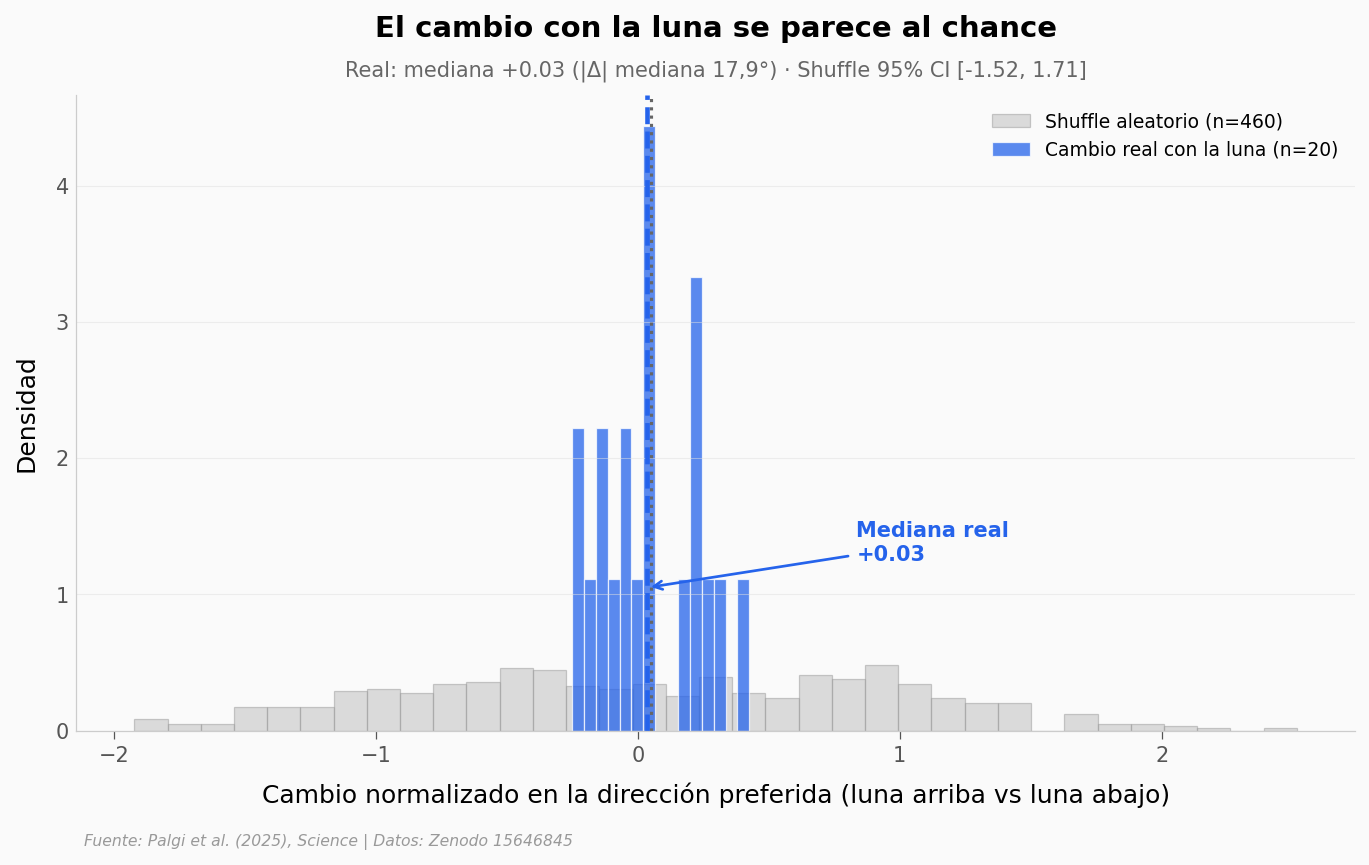

|Δ dirección preferida| real: mediana 17.9°, media 21.8°
Rango teórico posible: 0° a 180°
Mediana normalizada real: +0.034
Shuffle: media +0.053 ± 0.899 (SD)


In [5]:
# Histograma del cambio real (moon above vs below) vs shuffle
# Trabajamos con la versión normalizada (luna_shuffle) para comparación directa.

luna_norm = pd.read_csv('datos/luna_delta_normalizada.csv')
real_vals = luna_norm.normalized_delta_preferred_direction.values
shuffle_vals = luna_shuffle.shuffled_normalized_delta.values

fig, ax = plt.subplots(figsize=(11, 5.5))

# Shuffle (fondo gris)
ax.hist(shuffle_vals, bins=35, color=COLOR_SHUFFLE, alpha=0.5,
        edgecolor='#999999', linewidth=0.6,
        label=f'Shuffle aleatorio (n={len(shuffle_vals)})', density=True)

# Real (azul)
ax.hist(real_vals, bins=15, color=COLOR_DATOS, alpha=0.75,
        edgecolor='white', linewidth=0.6,
        label=f'Cambio real con la luna (n={len(real_vals)})', density=True)

# Mediana real vs shuffle
med_real = np.median(real_vals)
med_shuffle = np.median(shuffle_vals)
ax.axvline(med_real, color=COLOR_DATOS, linewidth=2.2, linestyle='--')
ax.axvline(med_shuffle, color='#666666', linewidth=1.5, linestyle=':')

ax.annotate(f'Mediana real\n{med_real:+.2f}',
            xy=(med_real, 1.05), xytext=(med_real + 0.8, 1.25),
            fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.3))

ax.set_xlabel('Cambio normalizado en la dirección preferida (luna arriba vs luna abajo)')
ax.set_ylabel('Densidad')
ax.set_title('El cambio con la luna se parece al chance',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Real: mediana {med_real:+.2f} (|Δ| mediana 17,9°) · '
        f'Shuffle 95% CI [{np.percentile(shuffle_vals, 2.5):.2f}, '
        f'{np.percentile(shuffle_vals, 97.5):.2f}]',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/luna_null_result.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuantificar: |Δ| mediana en grados (versión directa)
abs_delta = np.abs(luna_delta.delta_preferred_direction_deg.values)
print(f'|Δ dirección preferida| real: mediana {np.median(abs_delta):.1f}°, '
      f'media {np.mean(abs_delta):.1f}°')
print(f'Rango teórico posible: 0° a 180°')
print(f'Mediana normalizada real: {med_real:+.3f}')
print(f'Shuffle: media {np.mean(shuffle_vals):+.3f} ± {np.std(shuffle_vals):.3f} '
      f'(SD)')

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|:---:|---|
| Las células representan la dirección de manera estable a lo largo de la isla | ✅ | Dentro de sesión, ΔHD mediana real 50,5° vs shuffle 83,3°. Las reales están más concentradas que el chance (fracción <30° = 34,0% real vs 18,3% shuffle, ratio 1,86×). |
| La sintonía direccional se estabiliza a lo largo de varias noches | ✅ | Mediana noche 1: 1,72°/s → noche 6: 0,20°/s (reducción 8,4×). Spearman ρ = -0,60 (p < 1e-8). Cohen d = 1,43 (grande). **Diseño observacional** — el paper compara grupos distintos por noche, no manipula. |
| La brújula funciona sin importar la luna y la Vía Láctea | ✅ | Cambio \|Δ\| mediana 17,9° en un rango posible de 0° a 180°. Mediana normalizada +0,03 vs shuffle SD 0,90 (IC 95% ±1,7). El cambio real cae dentro del chance. **Es un resultado nulo** — los datos sugieren que la dirección preferida no depende de la luna, pero no "prueban" independencia. |
| "El primer registro en la selva" | ⚠️ | Contextual — no verificable desde los CSVs, pero el paper lo enmarca como un aporte metodológico nuevo. |

> **Limitaciones.** (1) Los 3 resultados se basan en datos agrupados a nivel célula; el Supplementary accesible no reporta el número exacto de murciélagos, así que el pseudo-replication por animal no se puede evaluar desde aquí. (2) El diseño es observacional: los splits luna-arriba/abajo y noche 1 vs noche 6 NO son manipulaciones experimentales — son comparaciones entre condiciones que varían naturalmente. (3) El paper escribe "imply" al concluir que la brújula es aprendida y fiable; los datos sugieren eso, pero no lo demuestran (esto requeriría manipular la experiencia, no solo medirla).

## Ahora tú

Tres preguntas con pista de código. Copia la celda de abajo y modifícala.

1. **¿Qué pasa si cambias la ventana de "primera noche"?** Si agrupas noches 1-2 vs 5-6, ¿el drift baja igual de claro? Pista: `estab_noche[estab_noche.night_num.isin([1,2])]` y `.isin([5,6])`.

2. **¿Qué células tienen el R más alto?** El vector de Rayleigh mide concentración: cuanto más cerca de 1, más selectiva. Pista: `ejemplos.groupby('cell_num').rayleigh_vector.first().sort_values()`.

3. **¿Cuánto "mueve" la luna a cada célula individual?** La mediana esconde los outliers. Pista: ordena `luna_delta` por `delta_preferred_direction_deg` y mira los extremos.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respondemos la pregunta 2: top 5 células por R (concentración direccional).

r_por_celula = (ejemplos.groupby('cell_num')
                        .rayleigh_vector.first()
                        .sort_values(ascending=False))

print('Ranking de células ejemplo por vector de Rayleigh (R):')
print('  — R = 0 significa disparo uniforme en todas las direcciones')
print('  — R = 1 significa concentración perfecta en una dirección')
print()
for i, (cnum, rval) in enumerate(r_por_celula.items(), 1):
    marker = '⭐' if rval > 0.8 else '  '
    print(f'{marker} #{i}  célula {int(cnum):>3}:  R = {rval:.3f}')

Ranking de células ejemplo por vector de Rayleigh (R):
  — R = 0 significa disparo uniforme en todas las direcciones
  — R = 1 significa concentración perfecta en una dirección

⭐ #1  célula  38:  R = 0.858
⭐ #2  célula  44:  R = 0.830


## Fuentes

**Paper**: [Head-direction cells as a neural compass in bats navigating outdoors on a remote oceanic island](https://doi.org/10.1126/science.adw6202)  
*Science, 2025-10-16*

**Datos**: [Data for 'Head-direction cells as a neural compass in bats navigating outdoors on a remote oceanic island'](https://doi.org/10.5281/zenodo.15646845)  
*Zenodo, 2025-06-12*

*14 afirmaciones verificadas contra estas fuentes*